In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [2]:
df_clean = pd.read_csv('../data/processed/card_profiler_clean.csv')
df_clean.head()

,BALANCE,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS
0,40.900749,95.40,0.00,95.4,0.000000,1000.0,201.802084
1,3202.467416,0.00,0.00,0.0,6442.945483,7000.0,4103.032597
2,2495.148862,773.17,773.17,0.0,0.000000,7500.0,622.066742
3,1666.670542,1499.00,1499.00,0.0,205.788017,7500.0,0.000000
4,817.714335,16.00,16.00,0.0,0.000000,1200.0,678.334763


In [3]:
columns_with_num = df_clean.select_dtypes(include='number').columns
df_clean.head()

,BALANCE,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS
0,40.900749,95.40,0.00,95.4,0.000000,1000.0,201.802084
1,3202.467416,0.00,0.00,0.0,6442.945483,7000.0,4103.032597
2,2495.148862,773.17,773.17,0.0,0.000000,7500.0,622.066742
3,1666.670542,1499.00,1499.00,0.0,205.788017,7500.0,0.000000
4,817.714335,16.00,16.00,0.0,0.000000,1200.0,678.334763


In [4]:
def log1p(df, columns):
    out = np.log1p(df[columns])
    out.columns = [f"{c}_log" for c in columns]
    return out

df_prepare_clustering = log1p(df_clean, columns_with_num)
df_prepare_clustering.to_csv('../data/processed/df_prepare_clustering.csv', index=False)
df_prepare_clustering.head(5)

,BALANCE_log,PURCHASES_log,ONEOFF_PURCHASES_log,INSTALLMENTS_PURCHASES_log,CASH_ADVANCE_log,CREDIT_LIMIT_log,PAYMENTS_log
0,3.735304,4.568506,0.000000,4.568506,0.000000,6.908755,5.312231
1,8.071989,0.000000,0.000000,0.000000,8.770896,8.853808,8.319725
2,7.822504,6.651791,6.651791,0.000000,0.000000,8.922792,6.434654
3,7.419183,7.313220,7.313220,0.000000,5.331694,8.922792,0.000000
4,6.707735,2.833213,2.833213,0.000000,0.000000,7.090910,6.521114


In [5]:
df_prepare_clustering.head(5)

,BALANCE_log,PURCHASES_log,ONEOFF_PURCHASES_log,INSTALLMENTS_PURCHASES_log,CASH_ADVANCE_log,CREDIT_LIMIT_log,PAYMENTS_log
0,3.735304,4.568506,0.000000,4.568506,0.000000,6.908755,5.312231
1,8.071989,0.000000,0.000000,0.000000,8.770896,8.853808,8.319725
2,7.822504,6.651791,6.651791,0.000000,0.000000,8.922792,6.434654
3,7.419183,7.313220,7.313220,0.000000,5.331694,8.922792,0.000000
4,6.707735,2.833213,2.833213,0.000000,0.000000,7.090910,6.521114


In [6]:
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_prepare_clustering)

In [7]:
df_scaled = pd.DataFrame(df_scaled, columns=df_prepare_clustering.columns, index=df_prepare_clustering.index)

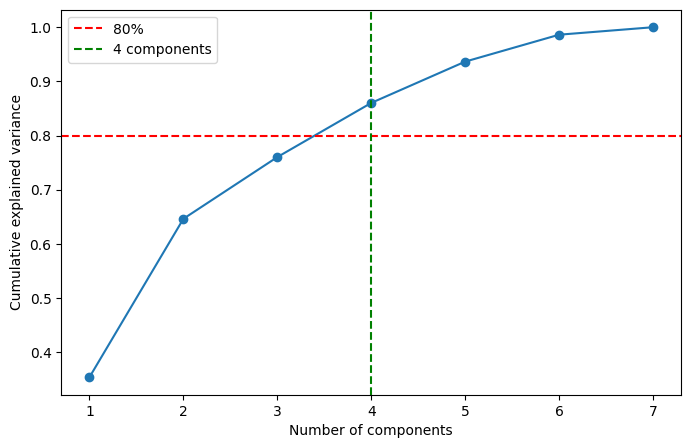

[0.354 0.293 0.114 0.1   0.076 0.05  0.014] -> n_80 = 4


In [ ]:
pca = PCA()
X_pca = pca.fit_transform(df_scaled)
df_pca = pd.DataFrame(X_pca, columns=[f"PC{i+1}" for i in range(X_pca.shape[1])], index=df_scaled.index)

cum_var = np.cumsum(pca.explained_variance_ratio_)
n_80 = np.argmax(cum_var >= 0.80) + 1

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cum_var) + 1), cum_var, marker="o")
plt.axhline(0.80, color="r", linestyle="--", label="80%")
plt.axvline(n_80, color="g", linestyle="--", label=f"{n_80} components")
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.legend()
plt.show()

print(pca.explained_variance_ratio_.round(3), "-> n_80 =", n_80)

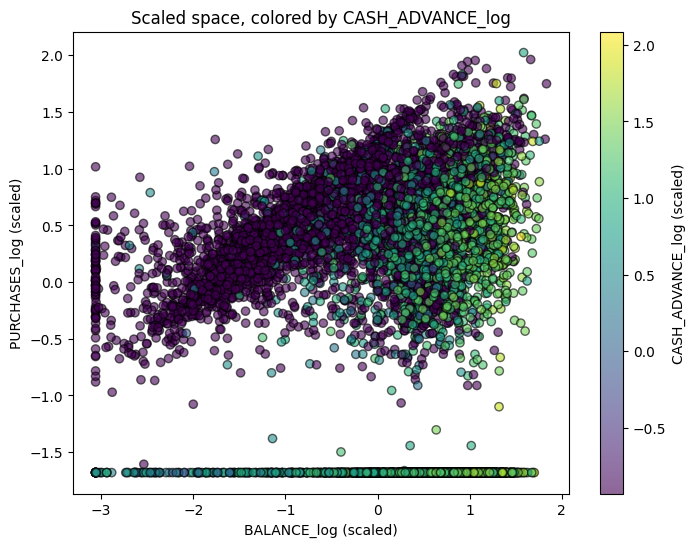

In [9]:
plt.figure(figsize=(8, 6))
sc = plt.scatter(df_scaled['BALANCE_log'], df_scaled['PURCHASES_log'], c=df_scaled['CASH_ADVANCE_log'], cmap='viridis', edgecolor='k', alpha=0.6)
plt.xlabel("BALANCE_log (scaled)")
plt.ylabel("PURCHASES_log (scaled)")
plt.title("Scaled space, colored by CASH_ADVANCE_log")
plt.colorbar(sc, label="CASH_ADVANCE_log (scaled)")
plt.show()

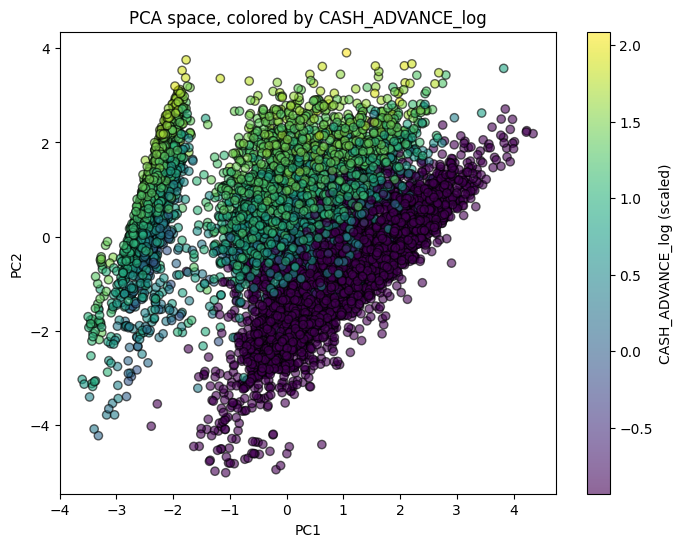

In [10]:
plt.figure(figsize=(8, 6))
sc = plt.scatter(df_pca['PC1'], df_pca['PC2'], c=df_scaled['CASH_ADVANCE_log'], cmap='viridis', edgecolor='k', alpha=0.6)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA space, colored by CASH_ADVANCE_log")
plt.colorbar(sc, label="CASH_ADVANCE_log (scaled)")
plt.show()

In [12]:
skew_compare = pd.DataFrame({
    "skew_before": df_clean[columns_with_num].skew().values,
    "skew_after": df_prepare_clustering.skew().values,
}, index=columns_with_num).round(2)
skew_compare

,skew_before,skew_after
BALANCE,2.39,-0.86
PURCHASES,8.14,-0.76
ONEOFF_PURCHASES,10.04,0.19
INSTALLMENTS_PURCHASES,7.30,-0.03
CASH_ADVANCE,5.17,0.26
CREDIT_LIMIT,1.52,-0.10
PAYMENTS,5.91,-1.78


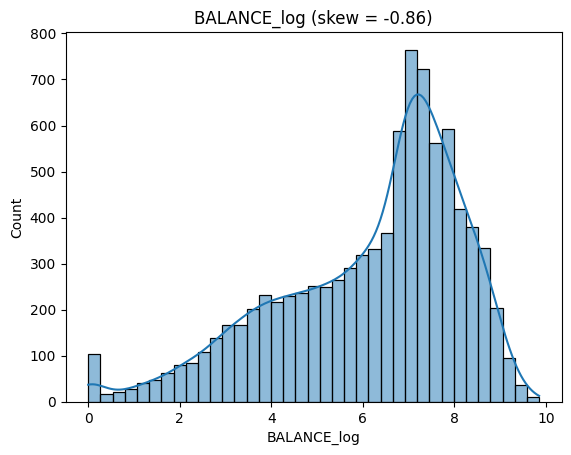

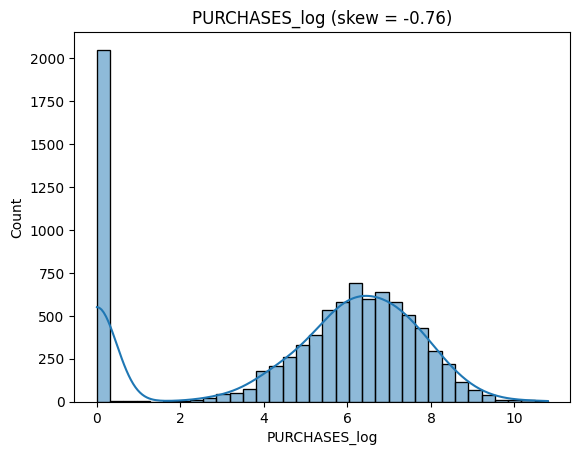

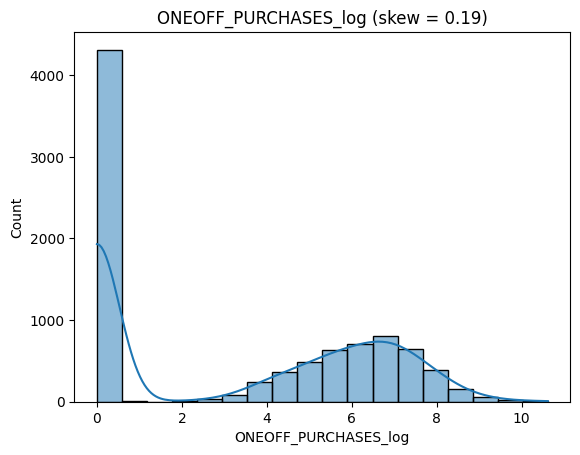

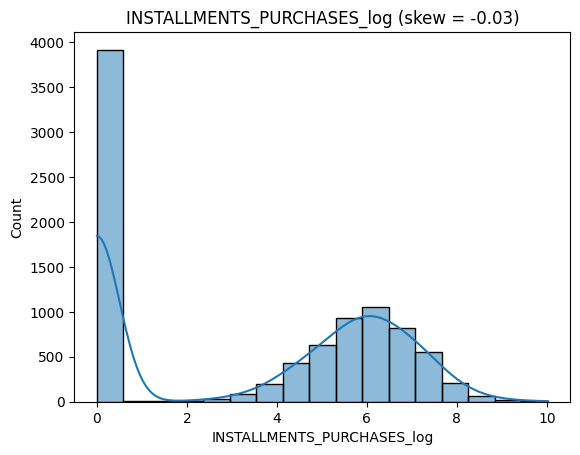

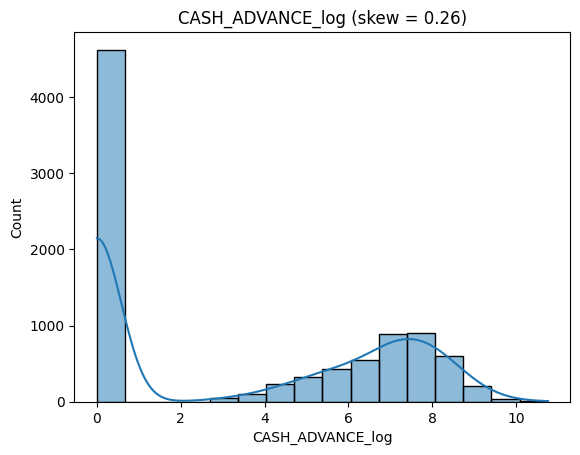

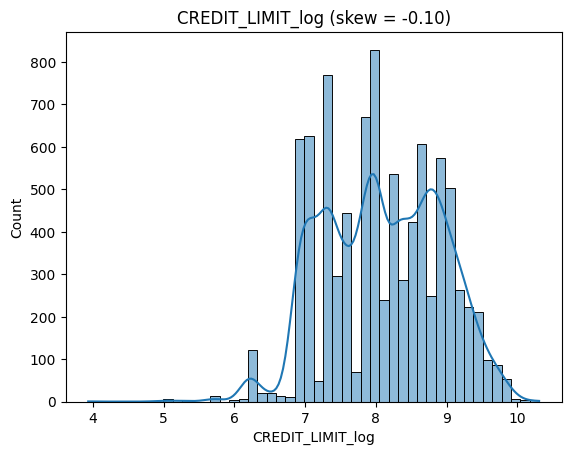

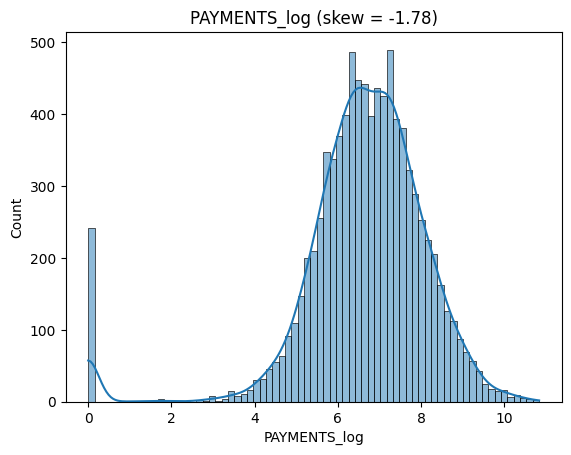

In [13]:
for col in df_prepare_clustering.columns:
    plt.figure()
    sns.histplot(df_prepare_clustering[col], kde=True)
    plt.title(f"{col} (skew = {df_prepare_clustering[col].skew():.2f})")

In [14]:
df_pca.to_csv('../data/processed/df_pca.csv', index=False)